## P31 — cross-entropy curves for the top-25 gradient parameters in each of the five p27 layers

Same model / image / layers / colors as `P25_37c`. For each of the five layers, the 25 weights with the largest
|dL/dw| at the trained weights (so `grad_index` 0..24, and the p27 picks are a subset) are swept over ±2.5 with
everything else at its trained value. Each sweep is rendered as **one static PNG** of the cross-entropy loss
`−ln P(correct)`: black background, gridlines, loss ticks on the left, y-limits = that curve's own min/max (+5%),
layer accent color, one shared crop across all 125 frames.

```
P31_curves/layer_k/grad_NN.png     k = 1..5 in the p27 ordering (1 = fc, magenta), NN = gradient rank 00..24
P31_curves/layer_k/curves.npy      (25 x 3 x N): [theta, P, loss] per rank
P31_curves/layer_k/summary.json    coord / flat_idx / w0 / grad / loss_ylim per rank, plus layer + color
```

In [1]:
BLUE="#2ca3dd"
YELLOW="#ffd35a"
RED='#ec2027'
CHILL_BROWN="#948979"

In [2]:
import json, gc, io, time
from pathlib import Path
from tqdm import tqdm
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.figure import Figure                      # OO figures: never registered with the notebook backend -> no RAM creep
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.transforms import Bbox
from torchvision.models.resnet import ResNet, BasicBlock
import torchvision.datasets as dsets, torchvision.transforms as T
from PIL import Image
from IPython.display import display

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'

RUNS   = Path("/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/aug_17_run")
DATA   = Path("/home/stephen/imagenet")
OUT    = Path("/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/P31_curves")
device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_DEPTHS = {"plain8": 8, "plain14": 14, "plain20": 20, "plain26": 26,
                "plain34": 34, "plain56": 56, "plain74": 74, "resnet74": 74}
print(torch.__version__, device)

2.12.1+cu130 cuda


### Model + data (same as P25_37c)

In [3]:
class PlainBasicBlock(BasicBlock):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.downsample = None

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        return out

LAYER_CFG = {8: [1,1,1,1], 14: [2,1,1,2], 20: [2,2,3,2], 26: [3,3,3,3],
             34: [4,4,4,4], 56: [3,4,17,3], 74: [3,4,26,3]}

def make_net(depth_target, use_skip, num_classes=1000):
    block = BasicBlock if use_skip else PlainBasicBlock
    model = ResNet(block, LAYER_CFG[depth_target], num_classes=num_classes)
    if depth_target == 8:
        model.layer4 = nn.Identity()
        model.fc = nn.Linear(256, num_classes)
    return model

def load_model(name, step=None):
    d = RUNS / name
    path = d / "final.pt" if step is None else d / f"ckpt_step{step:06d}.pt"
    model = make_net(MODEL_DEPTHS[name], use_skip=name.startswith("resnet"))
    model.load_state_dict(torch.load(path, map_location=device))
    return model.to(device).eval()

def weighted_layers(model):
    '''(name, module) for convs + fc in forward order, excluding 1x1 shortcuts.'''
    return [(n, m) for n, m in model.named_modules()
            if isinstance(m, (nn.Conv2d, nn.Linear)) and "downsample" not in n]

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
val_ds = dsets.ImageFolder(DATA / "ILSVRC/Data/CLS-LOC/val",
    T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor(), T.Normalize(MEAN, STD)]))

def load_image(idx):
    x, y = val_ds[idx]
    return x.unsqueeze(0).to(device), torch.tensor([y], device=device)

crit = nn.CrossEntropyLoss()

@torch.no_grad()
def correct_ans_conf(model, x, y):
    return F.softmax(model(x), dim=1)[0, y.item()].item()

def layer_grad(model, layer, x, y):
    '''dL/dw for one layer at the current weights.'''
    model.zero_grad(set_to_none=True)
    crit(model(x), y).backward()
    g = layer.weight.grad.detach().flatten().clone()
    model.zero_grad(set_to_none=True)
    return g

@torch.no_grad()
def sweep_weight(model, layer, flat_idx, x, y, span, n):
    '''Set one weight to each value in linspace(-span, span, n), record P(correct), restore. Returns (vals, res, w0).'''
    w = layer.weight.view(-1)
    w0 = w[flat_idx].item()
    vals = np.linspace(-span, span, n)
    res = np.empty(n)
    for i, v in enumerate(vals):
        w[flat_idx] = v
        res[i] = correct_ans_conf(model, x, y)
    w[flat_idx] = w0
    return vals, res, w0

def theta_latex(coord, layer_num):
    inner = r',\,'.join(str(int(c)) for c in coord)
    return r'$\theta_{(' + inner + r')}^{(' + str(layer_num) + r')}$'

## Config

In [4]:
MODEL_NAME = 'plain8'
IMG_IDX    = 39209                 # screwdriver
SPAN       = 2.5
N_POINTS   = 128
TOP_N      = 256                    # gradient ranks 0..24 per layer
PAD_FRAC   = 0.05                  # y-padding as a fraction of each curve's loss range
P_FLOOR    = 1e-12

# same layers + colors as P25_37c, same k ordering (k=1 is fc / magenta)
LAYERS = [
    dict(k=1, li=-1, color='m'),
    dict(k=2, li=-3, color='#eb8423'),
    dict(k=3, li=3,  color='#419c52'),
    dict(k=4, li=2,  color='#ed5e78'),
    dict(k=5, li=0,  color='#d73b2f'),
]

In [5]:
model = load_model(MODEL_NAME)
x, y  = load_image(IMG_IDX)
y_true = y.item()
base_conf = correct_ans_conf(model, x, y)
layers = weighted_layers(model)
print(f"P(true) at trained weights = {base_conf:.4f}   (loss {-np.log(base_conf):.4f})")

P(true) at trained weights = 0.0565   (loss 2.8735)


### Rank + sweep: top-25 |grad| per layer

In [6]:
for L in LAYERS:
    name, layer = layers[L['li']]
    g = layer_grad(model, layer, x, y)
    _, idxs = g.abs().topk(TOP_N)
    L.update(name=name, layer=layer, layer_num=L['li'] % len(layers) + 1, entries=[])
    for rank, flat_idx in enumerate(tqdm(idxs.tolist(), desc=f"layer {L['k']} {name}", leave=False)):
        vals, res, w0 = sweep_weight(model, layer, flat_idx, x, y, SPAN, N_POINTS)
        loss = -np.log(np.clip(res, P_FLOOR, None))
        lo, hi = loss.min(), loss.max(); pad = PAD_FRAC * (hi - lo)
        coord = tuple(int(c) for c in np.unravel_index(flat_idx, layer.weight.shape))
        L['entries'].append(dict(rank=rank, flat_idx=flat_idx, coord=coord, w0=w0, grad=g[flat_idx].item(),
                                 vals=vals, res=res, loss=loss, loss_ylim=(lo - pad, hi + pad),
                                 theta_label=theta_latex(coord, L['layer_num'])))
    assert abs(correct_ans_conf(model, x, y) - base_conf) < 1e-6, "weights not restored!"

for L in LAYERS:
    e0, e24 = L['entries'][0], L['entries'][-1]
    print(f"layer {L['k']}  {L['name']:<16} L{L['layer_num']}  |grad| rank0 = {abs(e0['grad']):.4f}  rank24 = {abs(e24['grad']):.4f}   "
          f"loss ranges: rank0 {e0['loss'].min():.2f}..{e0['loss'].max():.2f}, rank24 {e24['loss'].min():.2f}..{e24['loss'].max():.2f}")

layer 1  fc               L8  |grad| rank0 = 2.9646  rank24 = 0.1112   loss ranges: rank0 0.01..11.35, rank24 2.59..3.15
layer 2  layer3.0.conv1   L6  |grad| rank0 = 0.6833  rank24 = 0.2848   loss ranges: rank0 1.77..3.80, rank24 2.21..3.24
layer 3  layer2.0.conv1   L4  |grad| rank0 = 0.8745  rank24 = 0.2860   loss ranges: rank0 2.59..22.47, rank24 2.66..3.60
layer 4  layer1.0.conv2   L3  |grad| rank0 = 0.7455  rank24 = 0.2969   loss ranges: rank0 2.33..4.67, rank24 2.73..4.02
layer 5  conv1            L1  |grad| rank0 = 0.4665  rank24 = 0.2609   loss ranges: rank0 2.69..3.22, rank24 2.69..3.11


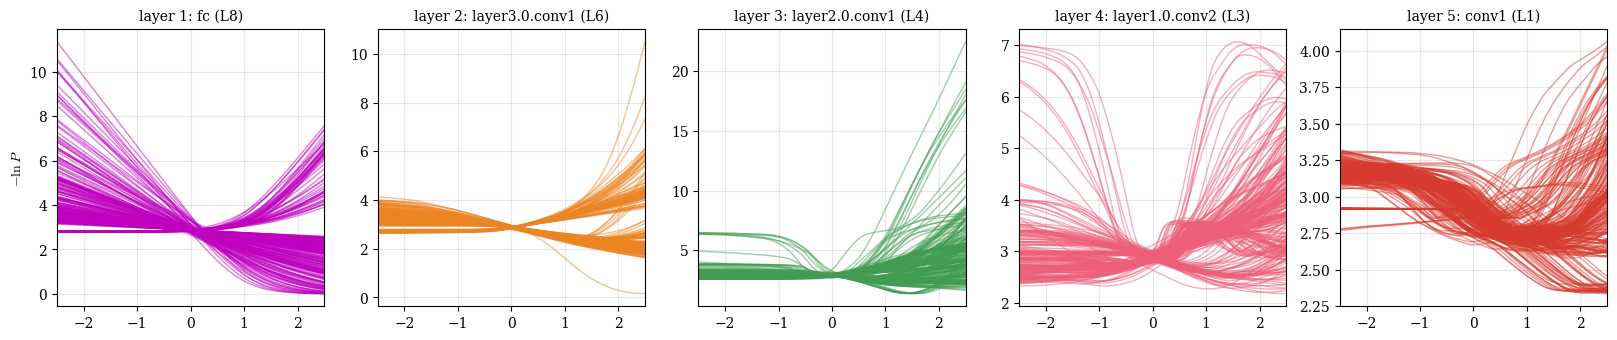

In [7]:
# overview: all 25 loss curves per layer, overlaid
fig, axes = plt.subplots(1, 5, figsize=(20, 3.6))
for ax, L in zip(axes, LAYERS):
    for e in L['entries']:
        ax.plot(e['vals'], e['loss'], c=L['color'], lw=1, alpha=0.5)
    ax.set_title(f"layer {L['k']}: {L['name']} (L{L['layer_num']})", fontsize=10)
    ax.set_xlim(-SPAN, SPAN); ax.grid(alpha=0.3)
axes[0].set_ylabel(r'$-\ln P$');

### Renderer + shared crop

In [8]:
FIGSIZE  = (6, 6)
DPI      = 300
CURVE_LW = 3
TICK_FS  = 12
SHOW_W0_DOT = False           # marker at the trained value (dot size below)
DOT_SIZE    = 125

def style_ax(ax, color=CHILL_BROWN):
    # ax.spines[:].set_visible(False)
    ax.spines[:].set_color(color)
    ax.tick_params(colors=color, which='both', labelsize=TICK_FS)

def fig_loss(e, color):
    fig = Figure(figsize=FIGSIZE, facecolor='k', dpi=DPI)
    ax = fig.add_subplot(111, facecolor='k')
    ax.plot(e['vals'], e['loss'], lw=CURVE_LW, c=color)
    if SHOW_W0_DOT:
        ax.scatter(e['w0'], -np.log(max(base_conf, P_FLOOR)), s=DOT_SIZE, c=color, zorder=10)
    ax.grid(True, color=CHILL_BROWN, alpha=0.3, linewidth=0.8)
    ax.set_xlim(-SPAN, SPAN); ax.set_ylim(*e['loss_ylim'])
    style_ax(ax)
    return fig

def save(fig, path, bbox):
    fig.savefig(path, dpi=DPI, bbox_inches=bbox)
    fig.clear()

# one crop for all 125 frames: union of each frame's tight box (the widest loss tick labels win)
boxes = []
for L in LAYERS:
    for e in L['entries']:
        f = fig_loss(e, L['color']); FigureCanvasAgg(f)
        boxes.append(f.get_tightbbox(f.canvas.get_renderer())); f.clear()
BBOX = Bbox.union(boxes).padded(0.1)
print('crop (inches):', np.round(BBOX.bounds, 3), '->', tuple(int(round(v * DPI)) for v in (BBOX.width, BBOX.height)), 'px')

crop (inches): [0.181 0.298 5.319 5.145] -> (1596, 1544) px


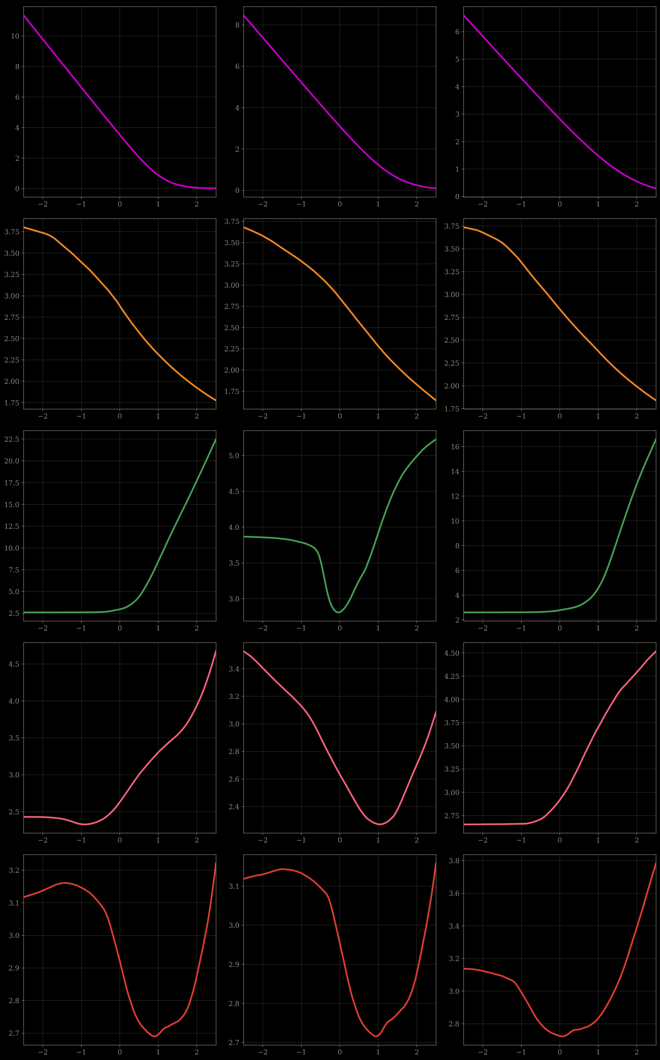

In [9]:
# preview: ranks 0, 12, 24 for each layer, through the real renderer
def preview(ranks=(0, 12, 24), width=220):
    rows = []
    for L in LAYERS:
        row = []
        for r in ranks:
            buf = io.BytesIO(); save(fig_loss(L['entries'][r], L['color']), buf, BBOX); buf.seek(0)
            im = Image.open(buf).convert('RGB'); row.append(im.resize((width, int(width * im.height / im.width))))
        rows.append(row)
    W, H = rows[0][0].size
    sheet = Image.new('RGB', (W * len(ranks), H * len(rows)), 'black')
    for r, row in enumerate(rows):
        for c, im in enumerate(row): sheet.paste(im, (c * W, r * H))
    display(sheet)
preview()

## Render

In [10]:
for L in LAYERS:
    d = OUT / f"layer_{L['k']}"; d.mkdir(parents=True, exist_ok=True)
    for e in tqdm(L['entries'], desc=f"layer {L['k']}", leave=False):
        save(fig_loss(e, L['color']), d / f"grad_{e['rank']:02d}.png", BBOX)
    gc.collect()
    np.save(d / 'curves.npy', np.stack([np.stack([e['vals'], e['res'], e['loss']]) for e in L['entries']]))
    json.dump({'layer_k': L['k'], 'li': L['li'], 'layer_name': L['name'], 'layer_num': L['layer_num'], 'color': L['color'],
               'model': MODEL_NAME, 'img_idx': IMG_IDX, 'class_idx': y_true, 'base_conf': base_conf,
               'span': SPAN, 'n_points': N_POINTS, 'pad_frac': PAD_FRAC, 'crop_inches': list(map(float, BBOX.bounds)),
               'entries': [{'rank': e['rank'], 'file': f"grad_{e['rank']:02d}.png", 'flat_idx': e['flat_idx'], 'coord': list(e['coord']),
                            'w0': e['w0'], 'grad': e['grad'], 'loss_ylim': list(map(float, e['loss_ylim'])),
                            'theta_label': e['theta_label']} for e in L['entries']]},
              open(d / 'summary.json', 'w'), indent=2)

sizes = {Image.open(f).size for f in OUT.rglob('grad_*.png')}
print(len(list(OUT.rglob('grad_*.png'))), 'frames written, sizes:', sizes)
assert len(sizes) == 1

1280 frames written, sizes: {(1595, 1543)}
